In [1]:
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
DB_PATH = '../data/market.db'
TRADING_DAYS_PER_YEAR = 252
%matplotlib inline

In [2]:
import re
conn = sqlite3.connect(DB_PATH)
preds = pd.read_sql("SELECT * FROM model_predictions", conn,
                    parse_dates=['matched_earnings_date'])
prices_long = pd.read_sql("SELECT date, ticker, close FROM prices", conn, parse_dates=['date'])
conn.close()

print(f'Predictions: {len(preds)} events, {preds["ticker"].nunique()} tickers')
print(f'Date range: {preds["matched_earnings_date"].min().date()} to {preds["matched_earnings_date"].max().date()}')
print(f'Prices: {len(prices_long):,} rows')

# ---- Column selection --------------------------------------------------
# The model may train on a TRANSFORMED target (e.g. abnormal_30d_va =
# demeaned + vol-adjusted sigma units). 04 then persists BOTH the residual
# prediction (predicted_*_va) and a recombined raw-space prediction
# (predicted_<raw> = residual*scale + persistence prior). Rank on the raw-
# space one when present (fair comparison to a raw-target model); PnL is
# always in raw return space — sigma units are not money.
pred_cols = sorted([c for c in preds.columns if c.startswith('predicted_')],
                   key=lambda c: c.endswith('_va'))   # raw-space first
TARGET = pred_cols[0].replace('predicted_', '') if pred_cols else 'abnormal_30d'
RAW_TARGET = re.sub(r'_va$', '', TARGET)
_pnl_col = (f'actual_{RAW_TARGET}' if f'actual_{RAW_TARGET}' in preds.columns
            else f'actual_{TARGET}')
actual_col = [_pnl_col] if _pnl_col in preds.columns else []
pred_col = [f'predicted_{TARGET}'] if pred_cols else []

print(f'\nTarget: {TARGET}  (PnL in raw {RAW_TARGET})')
print(f'Actual (PnL) col: {actual_col[0] if actual_col else "N/A"}')
print(f'Predicted (rank) col: {pred_col[0] if pred_col else "N/A"}')

if actual_col and pred_col:
    print(f'Actual mean={preds[actual_col[0]].mean():.5f}  std={preds[actual_col[0]].std():.5f}')
    print(f'Predicted mean={preds[pred_col[0]].mean():.5f}  std={preds[pred_col[0]].std():.5f}')
else:
    print('WARNING: No prediction columns found — check model_predictions table')

# ---- Holding period + costs -------------------------------------------
# Each trade earns the raw target's abnormal return over its window, so
# the holding period IS the raw-target horizon (abnormal_30d -> hold 30
# trading days). This drives the Sharpe annualization below.
_hm = re.search(r'(\d+)d', RAW_TARGET)
HOLD_DAYS = int(_hm.group(1)) if _hm else 1
PERIODS_PER_YEAR = 252 / HOLD_DAYS

# Transaction-cost assumptions (liquid large-cap; tune for your universe).
COST_BPS = 10.0            # round-trip spread + slippage per unit notional
BORROW_BPS_ANNUAL = 50.0   # short-leg borrow, annualized
print(f'\nHolding period: {HOLD_DAYS} trading days  ->  {PERIODS_PER_YEAR:.1f} periods/yr')
print(f'Costs: {COST_BPS:.0f} bps round-trip + {BORROW_BPS_ANNUAL:.0f} bps/yr borrow on shorts')

Predictions: 5130 events, 514 tickers
Date range: 2022-11-01 to 2025-05-15
Prices: 1,750,584 rows

Target: abnormal_30d  (PnL in raw abnormal_30d)
Actual (PnL) col: actual_abnormal_30d
Predicted (rank) col: predicted_abnormal_30d
Actual mean=-0.00905  std=0.10433
Predicted mean=-0.00154  std=0.02058

Holding period: 30 trading days  ->  8.4 periods/yr
Costs: 10 bps round-trip + 50 bps/yr borrow on shorts


In [3]:
# ---- Prepare trade-level data -----------------------------------------
# Only form long/short positions on dates with enough names to rank —
# with a single reporter, rank(pct=True) is always 1.0, which would
# force a spurious 100% long position on every isolated earnings date.
MIN_NAMES_PER_DATE = 5

if actual_col and pred_col:
    actual_c = actual_col[0]
    pred_c = pred_col[0]

    trades = preds[['ticker', 'matched_earnings_date', actual_c, pred_c]].copy()
    trades = trades.dropna(subset=[actual_c]).sort_values('matched_earnings_date')
    trades['rank'] = trades.groupby('matched_earnings_date')[pred_c].rank(pct=True)
    trades['n_names'] = trades.groupby('matched_earnings_date')['ticker'].transform('count')

    # Decile-based portfolio formation (only on dates with enough names)
    tradeable = trades['n_names'] >= MIN_NAMES_PER_DATE
    trades['long_signal'] = tradeable & (trades['rank'] >= 0.80)   # top 20%
    trades['short_signal'] = tradeable & (trades['rank'] <= 0.20)   # bottom 20%

    # Equal weight within each leg — vectorized (transform+where, instant)
    n_long_t = trades.groupby('matched_earnings_date')['long_signal'].transform('sum')
    n_short_t = trades.groupby('matched_earnings_date')['short_signal'].transform('sum')
    trades['long_weight'] = np.where(trades['long_signal'], 1.0 / n_long_t.clip(lower=1), 0.0)
    trades['short_weight'] = np.where(trades['short_signal'], -1.0 / n_short_t.clip(lower=1), 0.0)
    trades['portfolio_weight'] = trades['long_weight'] + trades['short_weight']

    # ---- Transaction costs per traded name --------------------------------
    # Round-trip spread/slippage on the traded notional, plus borrow on the
    # short leg accrued over the holding period. Longs pay no borrow.
    w_abs = trades['portfolio_weight'].abs()
    trades['cost'] = (w_abs * (COST_BPS / 1e4)
                      + (trades['portfolio_weight'] < 0) * w_abs
                        * (BORROW_BPS_ANNUAL / 1e4) * (HOLD_DAYS / 252))
    trades['portfolio_return_gross'] = trades[actual_c] * trades['portfolio_weight']
    trades['portfolio_return'] = trades['portfolio_return_gross'] - trades['cost']

    # Long-only benchmark: equal weight all tickers each date (gross)
    trades['ew_weight'] = 1.0 / trades['n_names']
    trades['ew_return'] = trades[actual_c] * trades['ew_weight']

    n_long = trades.groupby('matched_earnings_date')['long_signal'].sum()
    n_short = trades.groupby('matched_earnings_date')['short_signal'].sum()
    n_events = trades['matched_earnings_date'].nunique()
    n_dates_with_trades = (n_long > 0).sum()
    n_dates_tradeable = trades.loc[tradeable, 'matched_earnings_date'].nunique()
    print(f'Trade events: {n_events} earnings dates')
    print(f'Dates with >= {MIN_NAMES_PER_DATE} names (tradeable): {n_dates_tradeable}')
    print(f'Dates with >=1 long + >=1 short: {n_dates_with_trades}')
    print(f'Avg positions per event: {trades["long_signal"].mean()*100:.0f}% long, {trades["short_signal"].mean()*100:.0f}% short')
    print(f'Avg long picks per date: {n_long[n_long>0].mean():.1f}')
    print(f'Avg short picks per date: {n_short[n_short>0].mean():.1f}')
    print(f'Avg cost per event: {trades.groupby("matched_earnings_date")["cost"].sum().mean()*1e4:.1f} bps')
else:
    trades = None
    print('Skipping — no predictions data')

Trade events: 463 earnings dates
Dates with >= 5 names (tradeable): 247
Dates with >=1 long + >=1 short: 247
Avg positions per event: 21% long, 16% short
Avg long picks per date: 4.4
Avg short picks per date: 3.4
Avg cost per event: 13.8 bps


In [4]:
# ---- Portfolio metrics (holding-period-aware annualization) -----------
# Each "trade" earns the target's abnormal return over HOLD_DAYS trading
# days. We group same-day earnings into one portfolio return (an entry-date
# series) and annualize with sqrt(252 / HOLD_DAYS). For HOLD_DAYS=1 this is
# the usual daily sqrt(252).
#
# CAVEAT: with multi-day holds, positions entered on different dates overlap
# in time. This event-study Sharpe treats entry-date returns as independent
# periods; a real book holding the overlap would diversify across more names
# (usually helping risk-adjusted return) but is capital-constrained. Read the
# Sharpe as a signal-quality proxy, not a live track record.

def strat_series(returns_by_date):
    """Group same entry-date events into one portfolio return, sorted."""
    r = returns_by_date.dropna()
    if len(r) == 0:
        return r
    return r.groupby(pd.DatetimeIndex(r.index).normalize()).sum().sort_index()

def sharpe_ratio(returns, periods_per_year=None):
    """Annualized Sharpe from a series of per-period returns."""
    ppy = PERIODS_PER_YEAR if periods_per_year is None else periods_per_year
    if len(returns) < 2 or returns.std() == 0:
        return 0.0
    return np.sqrt(ppy) * returns.mean() / returns.std()

def strat_sharpe(returns_by_date):
    """Annualized Sharpe from date-indexed event returns."""
    return sharpe_ratio(strat_series(returns_by_date))

def max_drawdown(cumulative):
    peak = cumulative.cummax()
    return float(((cumulative - peak) / peak).min())

def compute_metrics(returns_by_date, label=''):
    """Standard portfolio metrics from date-indexed event returns."""
    s = strat_series(returns_by_date)
    if len(s) < 2:
        return {'label': label, 'n_trades': len(s), 'total_return': 0,
                'cagr': 0, 'sharpe': 0, 'max_dd': 0, 'win_rate': 0, 'avg_return': 0}
    cum = (1 + s).cumprod()
    total = float(cum.iloc[-1]) - 1
    years = max((s.index.max() - s.index.min()).days / 365.25, 1 / 12)
    return {
        'label': label, 'n_trades': len(s),
        'total_return': total, 'cagr': (1 + total) ** (1 / years) - 1,
        'sharpe': sharpe_ratio(s), 'max_dd': max_drawdown(cum),
        'win_rate': (s > 0).mean(), 'avg_return': s.mean(),
    }

In [5]:
if trades is not None:
    # Aggregate to event-level (entry-date) returns
    event_returns = trades.groupby('matched_earnings_date').agg(
        portfolio_return=('portfolio_return', 'sum'),
        portfolio_return_gross=('portfolio_return_gross', 'sum'),
        cost=('cost', 'sum'),
        ew_return=('ew_return', 'sum'),
        n_tickers=('ticker', 'count'),
        n_long=('long_signal', 'sum'),
        n_short=('short_signal', 'sum'),
        avg_actual=(actual_c, 'mean'),
    ).reset_index()
    event_returns = event_returns.sort_values('matched_earnings_date')

    print(f'Event-level returns: {len(event_returns)} dates')
    print(f'Dates with active positions: {(event_returns["n_long"] + event_returns["n_short"] > 0).sum()}')
else:
    event_returns = None

Event-level returns: 463 dates
Dates with active positions: 247


In [6]:
# ---- SPY benchmark (same holding window, vectorized) -------------------
import sys
sys.path.insert(0, '..')
from src.returns_calc import PriceMatrix

if event_returns is not None and len(prices_long) > 0:
    pm = PriceMatrix.from_long(prices_long[['date', 'ticker', 'close']])
    ev_dates = event_returns['matched_earnings_date'].to_numpy()
    spy_fwd = pm.forward_returns(np.full(len(ev_dates), 'SPY', dtype=object),
                                 ev_dates, HOLD_DAYS)
    event_returns['spy_return'] = np.nan_to_num(spy_fwd, nan=0.0)
    print(f'SPY benchmark ({HOLD_DAYS}d forward) aligned: {len(ev_dates)} events')
else:
    print('Skipping SPY benchmark')

SPY benchmark (30d forward) aligned: 463 events


In [7]:
if event_returns is not None:
    er = event_returns.set_index('matched_earnings_date')
    metrics = []
    metrics.append(compute_metrics(er['portfolio_return_gross'], 'Long/Short (gross)'))
    metrics.append(compute_metrics(er['portfolio_return'], 'Long/Short (net of costs)'))
    metrics.append(compute_metrics(er['ew_return'], 'Equal-Weight'))
    if 'spy_return' in er.columns:
        metrics.append(compute_metrics(er['spy_return'], f'SPY ({HOLD_DAYS}d)'))
    long_only = trades[trades['long_signal']].groupby('matched_earnings_date')[actual_c].mean()
    metrics.append(compute_metrics(long_only, 'Long-Only (top 20%)'))

    df_metrics = pd.DataFrame(metrics).set_index('label')
    print(f'=== Portfolio Performance ({HOLD_DAYS}d hold, {PERIODS_PER_YEAR:.0f} periods/yr) ===')
    print(df_metrics.round(4).to_string())

    g = df_metrics.loc['Long/Short (gross)', 'sharpe']
    n = df_metrics.loc['Long/Short (net of costs)', 'sharpe']
    print(f'\nCost drag on Sharpe: {g:+.2f} gross -> {n:+.2f} net')
else:
    df_metrics = None

=== Portfolio Performance (30d hold, 8 periods/yr) ===
                           n_trades  total_return     cagr  sharpe  max_dd  win_rate  avg_return
label                                                                                           
Long/Short (gross)              463      466.6892  10.3014  0.5810 -0.7120    0.3413      0.0164
Long/Short (net of costs)       463      248.2497   7.8171  0.5334 -0.7290    0.3391      0.0150
Equal-Weight                    463       -0.9148  -0.6215 -0.1731 -0.9606    0.4492     -0.0036
SPY (30d)                       463    24878.6543  53.1864  1.4259 -0.9240    0.6890      0.0232
Long-Only (top 20%)             247        3.4195   0.8051  0.3290 -0.5801    0.5020      0.0086

Cost drag on Sharpe: +0.58 gross -> +0.53 net


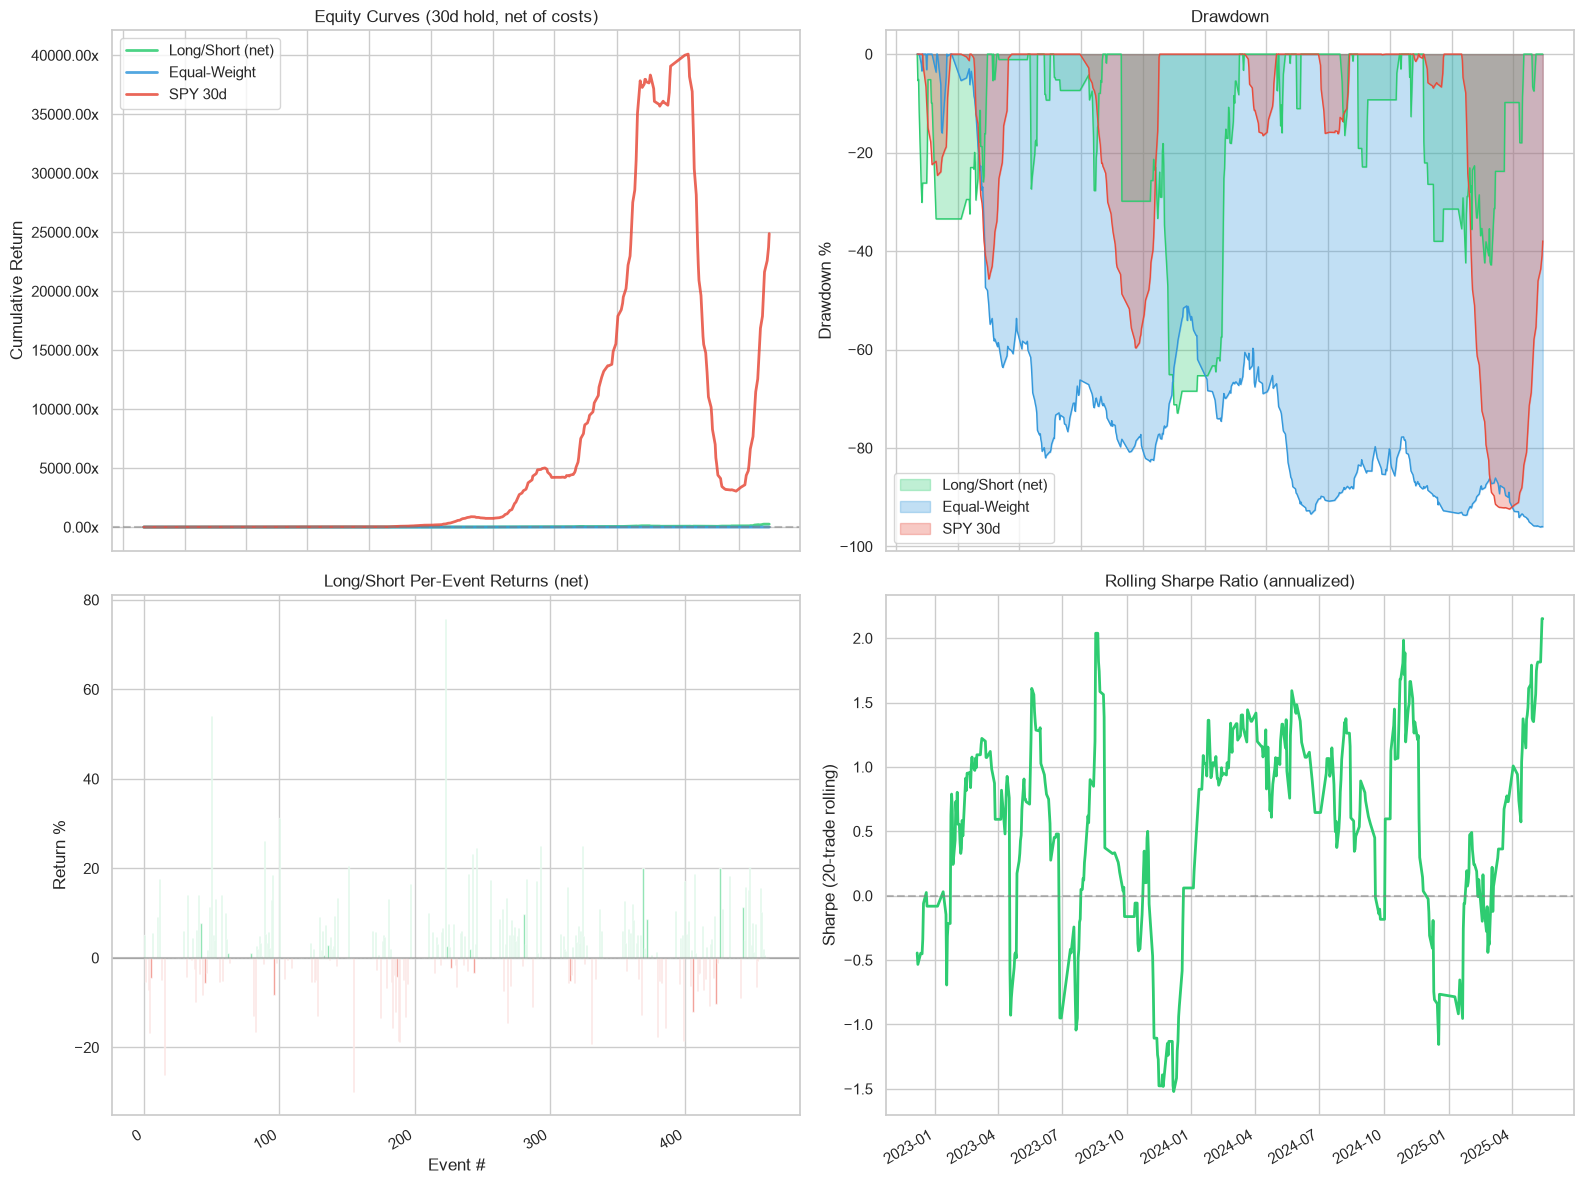

In [8]:
# ---- Equity curves (entry-date compounding, net of costs) --------------
if event_returns is not None and len(event_returns) > 2:
    er = event_returns.set_index('matched_earnings_date')
    series = {label: strat_series(er[col])
              for col, label in [('portfolio_return', 'Long/Short (net)'),
                                 ('ew_return', 'Equal-Weight'),
                                 ('spy_return', f'SPY {HOLD_DAYS}d')]
              if col in er.columns}
    colors = {'Long/Short (net)': '#2ecc71', 'Equal-Weight': '#3498db',
              f'SPY {HOLD_DAYS}d': '#e74c3c'}

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Cumulative returns
    ax = axes[0, 0]
    for label, s in series.items():
        cum = (1 + s).cumprod()
        ax.plot(cum.index, cum, label=label, color=colors[label],
                linewidth=2, alpha=0.85)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('Cumulative Return')
    ax.set_title(f'Equity Curves ({HOLD_DAYS}d hold, net of costs)')
    ax.legend(loc='best')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}x'))

    # 2. Drawdown
    ax = axes[0, 1]
    for label, s in series.items():
        cum = (1 + s).cumprod()
        peak = cum.cummax()
        dd = (cum - peak) / peak * 100
        ax.fill_between(dd.index, 0, dd, color=colors[label], alpha=0.3, label=label)
        ax.plot(dd.index, dd, color=colors[label], linewidth=1)
    ax.set_ylabel('Drawdown %')
    ax.set_title('Drawdown')
    ax.legend(loc='lower left')

    # 3. Per-event returns
    ax = axes[1, 0]
    x = np.arange(len(event_returns))
    ax.bar(x, event_returns['portfolio_return'].values * 100,
           color=np.where(event_returns['portfolio_return'] >= 0, '#2ecc71', '#e74c3c'),
           alpha=0.7, width=0.8)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('Event #')
    ax.set_ylabel('Return %')
    ax.set_title('Long/Short Per-Event Returns (net)')

    # 4. Rolling Sharpe over trades (20-trade window, annualized)
    ax = axes[1, 1]
    ls = series.get('Long/Short (net)')
    window = min(20, len(ls) // 4) if ls is not None else 0
    if ls is not None and window >= 4:
        rolling = ls.rolling(window).apply(
            lambda w: np.sqrt(PERIODS_PER_YEAR) * w.mean() / w.std()
            if w.std() > 0 else 0)
        ax.plot(rolling.index, rolling, color='#2ecc71', linewidth=2)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylabel(f'Sharpe ({window}-trade rolling)')
        ax.set_title('Rolling Sharpe Ratio (annualized)')

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for equity curves')

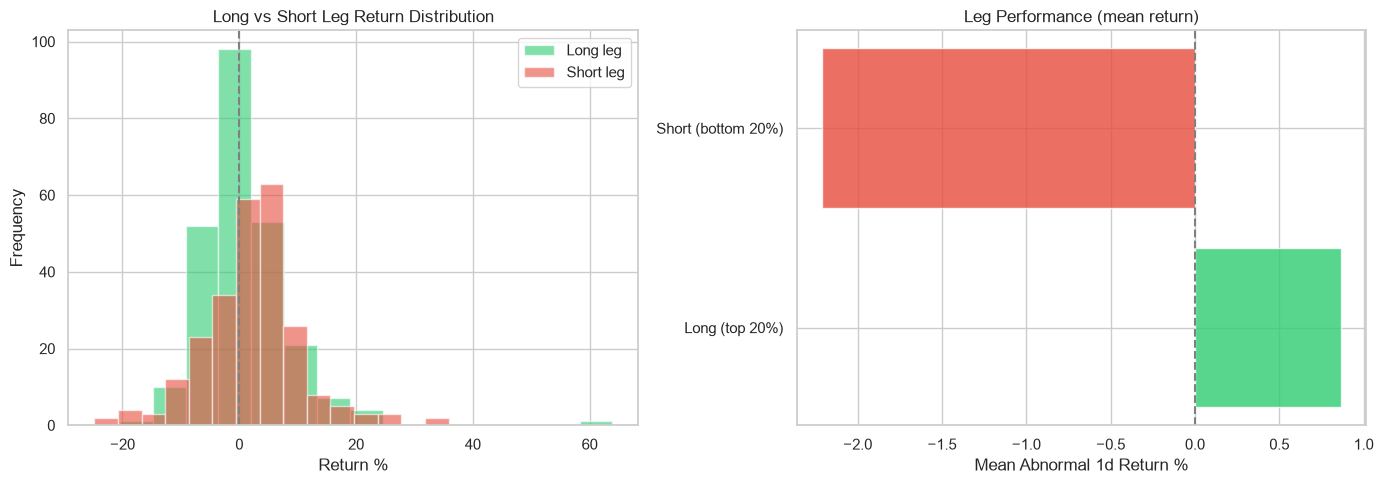

Long leg: mean=0.00863  hit rate=50.2%
Short leg (raw): mean=-0.02209  (stocks in bottom 20% go down on avg)
Short leg (pnl): mean=0.02209  hit rate=65.2%


In [9]:
# ---- Long vs Short decomposition -------------------------------------
if trades is not None:
    long_rets = trades[trades['long_signal']].groupby('matched_earnings_date')[actual_c].mean()
    short_rets_raw = trades[trades['short_signal']].groupby('matched_earnings_date')[actual_c].mean()
    # Short returns: we profit when shorted stocks go down
    short_rets = -short_rets_raw
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(long_rets.values * 100, bins=15, alpha=0.6, color='#2ecc71', edgecolor='white', label='Long leg')
    ax1.hist(short_rets.values * 100, bins=15, alpha=0.6, color='#e74c3c', edgecolor='white', label='Short leg')
    ax1.axvline(x=0, color='gray', linestyle='--')
    ax1.set_xlabel('Return %')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Long vs Short Leg Return Distribution')
    ax1.legend()
    
    ax2.barh(['Long (top 20%)', 'Short (bottom 20%)'],
             [long_rets.mean() * 100, short_rets_raw.mean() * 100],
             color=['#2ecc71', '#e74c3c'], alpha=0.8)
    ax2.axvline(x=0, color='gray', linestyle='--')
    ax2.set_xlabel('Mean Abnormal 1d Return %')
    ax2.set_title('Leg Performance (mean return)')
    
    plt.tight_layout()
    plt.show()
    
    print(f'Long leg: mean={long_rets.mean():.5f}  hit rate={(long_rets>0).mean():.1%}')
    print(f'Short leg (raw): mean={short_rets_raw.mean():.5f}  ' +
          f'(stocks in bottom 20% go {"up" if short_rets_raw.mean()>0 else "down"} on avg)')
    print(f'Short leg (pnl): mean={short_rets.mean():.5f}  hit rate={(short_rets>0).mean():.1%}')
else:
    print('Skipping — no trades')

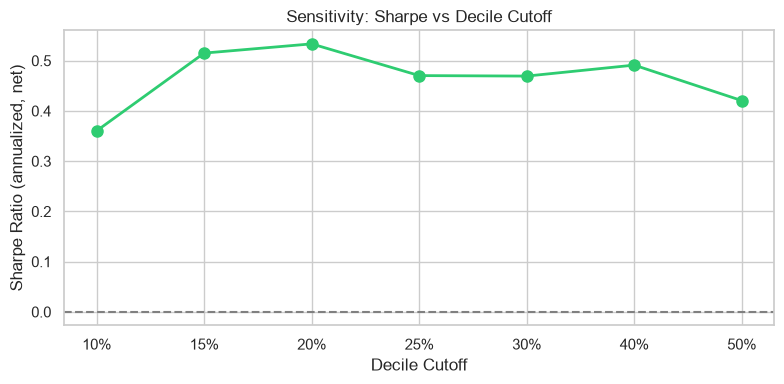

Sensitivity analysis (net of costs):
            sharpe  total_return  win_rate  avg_positions
cutoff_pct                                               
10%         0.3603       24.5060    0.3110         2.0194
15%         0.5151      164.2606    0.3283         3.0173
20%         0.5334      248.2497    0.3391         4.1663
25%         0.4703       81.4691    0.3391         5.1728
30%         0.4693       69.5427    0.3456         6.1058
40%         0.4912       34.9109    0.3283         8.1965
50%         0.4206       12.4626    0.3045        10.3348


In [10]:
# ---- Sensitivity: what if we change the decile cutoff? (net of costs) --
if trades is not None:
    cutoffs = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
    tradeable = trades['n_names'] >= MIN_NAMES_PER_DATE
    sens_results = []
    for cutoff in cutoffs:
        long_s = tradeable & (trades['rank'] >= (1 - cutoff))
        short_s = tradeable & (trades['rank'] <= cutoff)
        n_l = long_s.groupby(trades['matched_earnings_date']).transform('sum')
        n_s = short_s.groupby(trades['matched_earnings_date']).transform('sum')
        weight = (np.where(long_s, 1.0 / n_l.clip(lower=1), 0.0)
                  - np.where(short_s, 1.0 / n_s.clip(lower=1), 0.0))
        w_abs = np.abs(weight)
        cost = (w_abs * (COST_BPS / 1e4)
                + (weight < 0) * w_abs * (BORROW_BPS_ANNUAL / 1e4) * (HOLD_DAYS / 252))
        pnl = trades[actual_c].values * weight - cost
        event_pnl = pd.Series(pnl, index=trades['matched_earnings_date']).groupby(level=0).sum()
        cum = (1 + event_pnl).prod()
        sens_results.append({
            'cutoff_pct': f'{cutoff*100:.0f}%',
            'sharpe': strat_sharpe(event_pnl),   # holding-period annualized
            'total_return': cum - 1,
            'win_rate': (event_pnl > 0).mean(),
            'avg_positions': (long_s.sum() + short_s.sum()) / trades['matched_earnings_date'].nunique()
        })
    df_sens = pd.DataFrame(sens_results).set_index('cutoff_pct')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_sens.index, df_sens['sharpe'], 'o-', color='#2ecc71', linewidth=2, markersize=8)
    ax.axhline(y=0, color='gray', linestyle='--')
    ax.set_xlabel('Decile Cutoff')
    ax.set_ylabel('Sharpe Ratio (annualized, net)')
    ax.set_title('Sensitivity: Sharpe vs Decile Cutoff')
    plt.tight_layout()
    plt.show()

    print('Sensitivity analysis (net of costs):')
    print(df_sens.round(4).to_string())
else:
    print('Skipping — no trades')

## Backtest Summary

Long/short strategy on the model's predictions:

1. **Signal**: on each earnings date, rank stocks by model-predicted abnormal return
2. **Long**: top 20% (equal weight) — **Short**: bottom 20% (equal weight)
3. **Hold**: `HOLD_DAYS` trading days, inferred from the target
   (`abnormal_30d` → 30-day post-earnings-drift hold; `abnormal_1d` → 1-day)
4. **Tradeable dates**: only earnings dates with ≥ 5 reporting names
   (percentile ranks are meaningless with 1–2 names)

### Costs (net figures are the headline)
- `COST_BPS` round-trip spread + slippage on traded notional
- `BORROW_BPS_ANNUAL` on the short leg, accrued over the holding period
- Reported as **gross vs. net** so the cost drag is explicit

### Metrics
- **Sharpe** — entry-date portfolio returns annualized by √(252 / HOLD_DAYS)
- **Max drawdown**, **CAGR**, **win rate**, **leg decomposition**, **cutoff sensitivity**

### Benchmarks
- Equal-weight portfolio of all names reporting that date
- SPY over the same holding window
- Long-only (top 20%, no short)

### Caveats
- **Overlapping holds**: with a multi-day hold, positions entered on different
  dates overlap in time. The event-study Sharpe treats entry-date returns as
  independent periods — read it as signal quality, not a live track record. A
  real book would diversify across the overlap (helps) but is capital-constrained.
- No market impact; assumes execution at the close.
- Predictions come from notebook 04's untouched eval region (last ~30% of
  events), so the backtest window is shorter than the full sample.